In [2]:
#Cell 1: setup and load (self-contained)
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from src.utils import load_config, set_seed, setup_plotting, save_figure
from src.evaluation.metrics import evaluate_model
from src.cross_dataset.alignment import FEATURE_NAME_MAP_2017_TO_UNSW

cfg = load_config()
set_seed(cfg["project"]["random_state"])
setup_plotting(cfg)
seed = cfg["project"]["random_state"]
proc = cfg["paths"]["processed_dir"]

# Source (CICIDS2017) - 20 selected features
X_train = pd.read_parquet(os.path.join(proc, "X_train_selected.parquet"))
X_test = pd.read_parquet(os.path.join(proc, "X_test_selected.parquet"))
y_train = pd.read_parquet(os.path.join(proc, "y_train.parquet"))["label_binary"]
y_test = pd.read_parquet(os.path.join(proc, "y_test.parquet"))["label_binary"]

# Targets (saved earlier for the live demo)
def load_target(x_name, y_name):
    X = pd.read_parquet(os.path.join(proc, x_name))
    y = pd.read_parquet(os.path.join(proc, y_name))["label_binary"]
    return X, y

X_2018, y_2018 = load_target("cross_dataset_2018_X.parquet", "cross_dataset_2018_y.parquet")
X_unsw, y_unsw = load_target("cross_dataset_unsw_X.parquet", "cross_dataset_unsw_y.parquet")
X_dd19, y_dd19 = load_target("cross_dataset_ddos2019_X.parquet", "cross_dataset_ddos2019_y.parquet")

features_20 = list(X_train.columns)
features_7 = list(FEATURE_NAME_MAP_2017_TO_UNSW.keys())

print("20-feature set:", len(features_20), "| 7-feature set:", len(features_7))
print("2018:", X_2018.shape, "| UNSW:", X_unsw.shape, "| CICDDoS2019:", X_dd19.shape)

20-feature set: 20 | 7-feature set: 7
2018: (561110, 20) | UNSW: (126385, 7) | CICDDoS2019: (260591, 20)


In [3]:
#Cell 2: train all models and evaluate on every target
def build_models(spw):
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=seed)),
        ]),
        "Decision Tree": DecisionTreeClassifier(
            class_weight="balanced", max_depth=10, random_state=seed),
        "Random Forest": RandomForestClassifier(
            n_estimators=150, max_depth=15, min_samples_split=5, min_samples_leaf=1,
            max_features="sqrt", class_weight="balanced", random_state=seed, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=100, max_depth=6, scale_pos_weight=spw,
            random_state=seed, n_jobs=-1, eval_metric="logloss"),
    }

records = []

def run_experiment(feature_list, set_name, eval_sets):
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    for name, model in build_models(spw).items():
        model.fit(X_train[feature_list], y_train)
        for ds_name, (Xe, ye) in eval_sets.items():
            m = evaluate_model(model, Xe[feature_list], ye, model_name=name)
            m["feature_set"] = set_name
            m["evaluated_on"] = ds_name
            records.append(m)
            print(f"[{set_name}] {name:<20} -> {ds_name:<28} F1={m['f1']:.4f}  AUC={m['roc_auc']:.4f}  FNR={m['fnr']:.4f}")

# 20-feature experiments: in-dataset + 2018 + CICDDoS2019
run_experiment(features_20, "20 features", {
    "CICIDS2017 (in-dataset)": (X_test, y_test),
    "CSE-CIC-IDS2018": (X_2018, y_2018),
    "CICDDoS2019": (X_dd19, y_dd19),
})

# 7-feature experiments: in-dataset + UNSW-NB15
run_experiment(features_7, "7 features", {
    "CICIDS2017 (in-dataset)": (X_test, y_test),
    "UNSW-NB15": (X_unsw, y_unsw),
})

[20 features] Logistic Regression  -> CICIDS2017 (in-dataset)      F1=0.9896  AUC=0.9996  FNR=0.0014
[20 features] Logistic Regression  -> CSE-CIC-IDS2018              F1=0.0000  AUC=0.9864  FNR=1.0000
[20 features] Logistic Regression  -> CICDDoS2019                  F1=0.0326  AUC=0.4124  FNR=0.9835
[20 features] Decision Tree        -> CICIDS2017 (in-dataset)      F1=0.9998  AUC=0.9999  FNR=0.0002
[20 features] Decision Tree        -> CSE-CIC-IDS2018              F1=0.0000  AUC=0.5874  FNR=1.0000
[20 features] Decision Tree        -> CICDDoS2019                  F1=0.0016  AUC=0.4454  FNR=0.9992
[20 features] Random Forest        -> CICIDS2017 (in-dataset)      F1=0.9999  AUC=1.0000  FNR=0.0001
[20 features] Random Forest        -> CSE-CIC-IDS2018              F1=0.0000  AUC=0.6004  FNR=1.0000
[20 features] Random Forest        -> CICDDoS2019                  F1=0.0000  AUC=0.6980  FNR=1.0000
[20 features] XGBoost              -> CICIDS2017 (in-dataset)      F1=0.9999  AUC=1.0000  F

In [4]:
#Cell 3: results table and save
results = pd.DataFrame(records)
cols = ["feature_set", "model", "evaluated_on", "accuracy", "precision",
        "recall", "f1", "roc_auc", "fpr", "fnr"]
results = results[cols]

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", None)
print(results.round(4).to_string(index=False))

results.to_csv(os.path.join(cfg["paths"]["metrics_dir"], "multi_model_cross_dataset.csv"), index=False)
print("\nSaved multi_model_cross_dataset.csv")

feature_set               model            evaluated_on  accuracy  precision  recall     f1  roc_auc    fpr    fnr
20 features Logistic Regression CICIDS2017 (in-dataset)    0.9879     0.9807  0.9986 0.9896   0.9996 0.0264 0.0014
20 features Logistic Regression         CSE-CIC-IDS2018    0.6423     0.0000  0.0000 0.0000   0.9864 0.0004 1.0000
20 features Logistic Regression             CICDDoS2019    0.0301     0.9979  0.0165 0.0326   0.4124 0.0025 0.9835
20 features       Decision Tree CICIDS2017 (in-dataset)    0.9998     0.9998  0.9998 0.9998   0.9999 0.0002 0.0002
20 features       Decision Tree         CSE-CIC-IDS2018    0.6424     0.0000  0.0000 0.0000   0.5874 0.0002 1.0000
20 features       Decision Tree             CICDDoS2019    0.0146     1.0000  0.0008 0.0016   0.4454 0.0000 0.9992
20 features       Random Forest CICIDS2017 (in-dataset)    0.9999     0.9999  0.9999 0.9999   1.0000 0.0001 0.0001
20 features       Random Forest         CSE-CIC-IDS2018    0.6425     0.0000  0.

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\multi_model_cross_dataset_heatmap.png


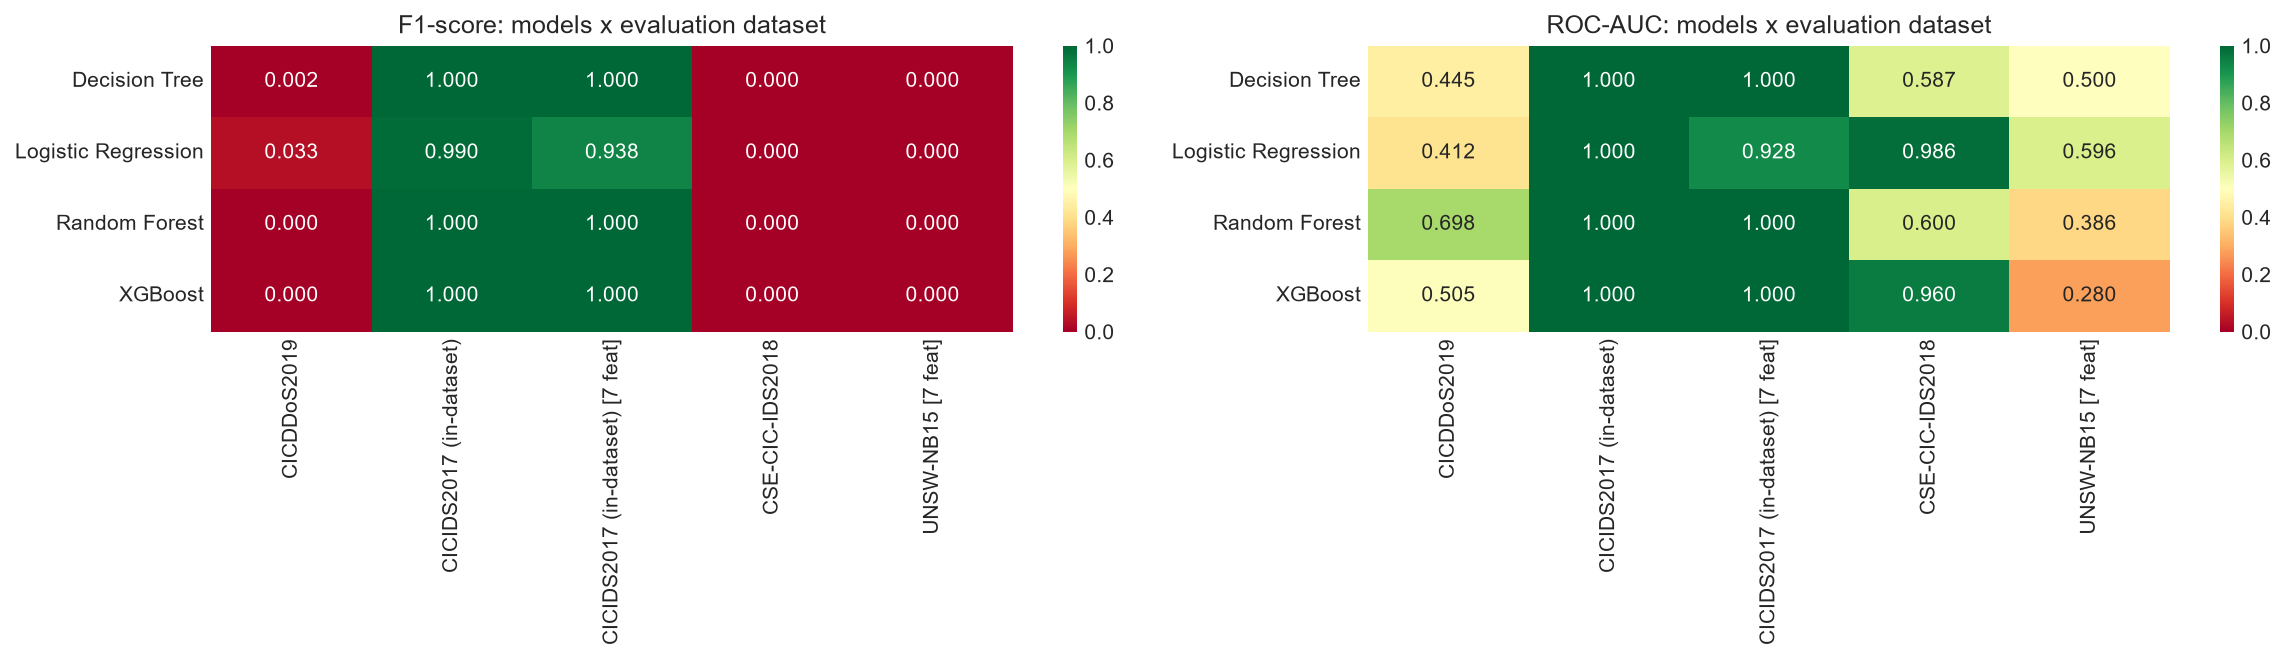

In [5]:
#Cell 4: heatmaps (report-ready figure)
results["setting"] = np.where(
    results["feature_set"] == "7 features",
    results["evaluated_on"] + " [7 feat]",
    results["evaluated_on"],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, metric, title in zip(axes, ["f1", "roc_auc"], ["F1-score", "ROC-AUC"]):
    pivot = results.pivot(index="model", columns="setting", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"{title}: models x evaluation dataset")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
save_figure(fig, "multi_model_cross_dataset_heatmap.png", cfg)
plt.show()

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

rows = []
spw = (y_train == 0).sum() / (y_train == 1).sum()

plan = [
    (features_20, "20 features", {"CSE-CIC-IDS2018": (X_2018, y_2018), "CICDDoS2019": (X_dd19, y_dd19)}),
    (features_7, "7 features", {"UNSW-NB15": (X_unsw, y_unsw)}),
]

for feats, set_name, targets in plan:
    for name, model in build_models(spw).items():
        model.fit(X_train[feats], y_train)
        for ds, (Xe, ye) in targets.items():
            proba = model.predict_proba(Xe[feats])[:, 1]
            p, r, t = precision_recall_curve(ye, proba)
            f1s = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
            i = int(np.argmax(f1s))
            prev = float(ye.mean())
            trivial_f1 = 2 * prev / (1 + prev)   # F1 if we label EVERYTHING as attack
            rows.append({
                "target": ds, "model": name, "prevalence": prev,
                "roc_auc": roc_auc_score(ye, proba),
                "pr_auc": average_precision_score(ye, proba),
                "best_f1": float(f1s[i]), "best_threshold": float(t[i]),
                "trivial_all_attack_f1": trivial_f1,
                "gain_over_trivial": float(f1s[i]) - trivial_f1,
            })

thr = pd.DataFrame(rows)
pd.set_option("display.width", 220)
print(thr.round(4).to_string(index=False))
thr.to_csv(os.path.join(cfg["paths"]["metrics_dir"], "threshold_analysis_all_models.csv"), index=False)

         target               model  prevalence  roc_auc  pr_auc  best_f1  best_threshold  trivial_all_attack_f1  gain_over_trivial
CSE-CIC-IDS2018 Logistic Regression      0.3575   0.9864  0.9526   0.9911             0.0                 0.5267             0.4644
    CICDDoS2019 Logistic Regression      0.9862   0.4124  0.9811   0.9931             0.0                 0.9931             0.0000
CSE-CIC-IDS2018       Decision Tree      0.3575   0.5874  0.4694   0.5267             0.0                 0.5267             0.0000
    CICDDoS2019       Decision Tree      0.9862   0.4454  0.9858   0.9931             0.0                 0.9931             0.0000
CSE-CIC-IDS2018       Random Forest      0.3575   0.6004  0.4748   0.5267             0.0                 0.5267             0.0000
    CICDDoS2019       Random Forest      0.9862   0.6980  0.9913   0.9931             0.0                 0.9931             0.0000
CSE-CIC-IDS2018             XGBoost      0.3575   0.9601  0.9398   0.9430   

In [7]:
print(thr.assign(best_threshold=thr.best_threshold.map("{:.3e}".format))[["target","model","best_threshold","best_f1"]].to_string(index=False))

         target               model best_threshold  best_f1
CSE-CIC-IDS2018 Logistic Regression      3.626e-16 0.991052
    CICDDoS2019 Logistic Regression     7.131e-142 0.993068
CSE-CIC-IDS2018       Decision Tree      0.000e+00 0.526692
    CICDDoS2019       Decision Tree      0.000e+00 0.993058
CSE-CIC-IDS2018       Random Forest      0.000e+00 0.526692
    CICDDoS2019       Random Forest      0.000e+00 0.993058
CSE-CIC-IDS2018             XGBoost      1.143e-05 0.942991
    CICDDoS2019             XGBoost      6.693e-07 0.993075
      UNSW-NB15 Logistic Regression      9.694e-09 0.629363
      UNSW-NB15       Decision Tree      0.000e+00 0.611932
      UNSW-NB15       Random Forest      0.000e+00 0.611932
      UNSW-NB15             XGBoost      9.644e-07 0.612104


In [8]:
import os, json
from src.utils import load_config
cfg = load_config()
p = os.path.join(cfg["paths"]["reports_dir"], "cross_dataset_all_results.json")
d = json.load(open(p))

d["cse_cic_ids2018"]["notes"] = ("Final RF: no threshold beats the trivial baseline. LR and XGBoost keep ranking "
    "signal (ROC-AUC 0.986/0.960; oracle best F1 0.991/0.943 vs baseline 0.527), i.e. default-threshold "
    "miscalibration. KS analysis shows packet-length features among the most shifted.")
d["cicddos2019"]["notes"] = ("Class is 98.6% attack, so F1 is dominated by prevalence. No model beats the "
    "'flag everything' baseline (F1 0.9931) at any threshold: no usable signal.")
d["cicddos2019"]["best_f1_any_threshold"] = 0.9931
d["cicddos2019"]["trivial_baseline_f1"] = 0.9931
d["unsw_nb15"]["notes"] = ("7-feature model. No model beats the 'flag everything' baseline (F1 0.612) by more "
    "than 0.02. Init_Win_bytes_* are semantically mismatched (0-255 vs 16-bit range).")

json.dump(d, open(p, "w"), indent=2)
print("updated")

updated


In [9]:
print(thr[["target", "model", "best_threshold", "best_f1"]].to_string(
    index=False, formatters={"best_threshold": lambda x: f"{x:.8f}"}
))

         target               model best_threshold  best_f1
CSE-CIC-IDS2018 Logistic Regression     0.00000000 0.991052
    CICDDoS2019 Logistic Regression     0.00000000 0.993068
CSE-CIC-IDS2018       Decision Tree     0.00000000 0.526692
    CICDDoS2019       Decision Tree     0.00000000 0.993058
CSE-CIC-IDS2018       Random Forest     0.00000000 0.526692
    CICDDoS2019       Random Forest     0.00000000 0.993058
CSE-CIC-IDS2018             XGBoost     0.00001143 0.942991
    CICDDoS2019             XGBoost     0.00000067 0.993075
      UNSW-NB15 Logistic Regression     0.00000001 0.629363
      UNSW-NB15       Decision Tree     0.00000000 0.611932
      UNSW-NB15       Random Forest     0.00000000 0.611932
      UNSW-NB15             XGBoost     0.00000096 0.612104
